# Лабораторна робота №7. Структури даних дерево, купа, геш-таблиця 

##### AUTHOR

© Kremliakov Hlib

### Мета

Засвоїти основні функції та алгоритми роботи з деревами та купою засобами Python.

## Хід роботи

### Завдання

Реалізувати контрольні приклади.

− Створити бінарне дерево згідно з варіантом, виданим викладачем. 

− Написати процедуру видалення заданої гілки дерева. 

− Оцінити асимптотичну складність (в середньому і в найгіршому 
випадку) процедур search, insert і delete роботи з деревом.

− Написати процедуру генерації купи з будь-якого рандомного масива. 

− Додати до нього елемент, який дорівнює вашому порядковому номеру у списку групи. 

− Вилучити максимальний елемент з купи. 

− Оцінити асимптотичну складність (у середньому і в найгіршому випадку) процедур search, insert і delete роботи з купою. 

− Вивчіть самостійно різні методи розв’язання колізій.
   
− Реалізуйте геш-таблицю з ланцюжковим гешуванням.

− Проведіть тестування геш-таблиці з різними типами даних (цілі числа, рядки, списки, словники, об’єкти): – перевірити працездатність геш-таблиці з різними типами даних. – виміряти час виконання основних операцій (пошук, вставка, видалення) для різних типів даних. – порівняти результати для різних типів даних.

## Виконання

In [1]:
# Створення дерева
def BinaryTree(r):
    return [r, [], []]

# Вставка в ліве піддерево
def insertLeft(root, newBranch):

    t = root.pop(1)

    if len(t) > 1:
        root.insert(1, [newBranch, t, []])
    else:
        root.insert(1, [newBranch, [], []])

    return root

# Вставка в праве піддерево
def insertRight(root, newBranch):

    t = root.pop(2)

    if len(t) > 1:
        root.insert(2, [newBranch, [], t])
    else:
        root.insert(2, [newBranch, [], []])

    return root

# Отримати корінь
def getRootVal(root):
    return root[0]

# Змінити корінь
def setRootVal(root, newVal):
    root[0] = newVal

# Лівий нащадок
def getLeftChild(root):
    return root[1]

# Правий нащадок
def getRightChild(root):
    return root[2]

### Приклад дерева

In [2]:
r = BinaryTree('A')

insertLeft(r, 'B')
insertRight(r, 'C')

insertLeft(getLeftChild(r), 'D')
insertRight(getLeftChild(r), 'E')

print(r)

['A', ['B', ['D', [], []], ['E', [], []]], ['C', [], []]]


### Видалення лівої гілки

In [3]:
def deleteLeft(root):

    root[1] = []

    return root

### Видалення правої гілки

In [4]:
def deleteRight(root):

    root[2] = []

    return root

### Перевірка

In [5]:
print("До видалення:")
print(r)

deleteLeft(r)

print("Після видалення:")
print(r)

До видалення:
['A', ['B', ['D', [], []], ['E', [], []]], ['C', [], []]]
Після видалення:
['A', [], ['C', [], []]]


## Асимптотична складність операцій дерева

### Search
Складність: 

У найгіршому випадку потрібно переглянути всі вузли дерева.

### Insert
Складність: 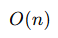

Пошук місця вставки може вимагати проходу дерева.

### Delete
Складність: 

Видалення вузла може потребувати перебудови дерева.

## Купа (Heap)

In [6]:
heap = [0]
currSize = 0

In [7]:
def parent(i):
    return i // 2

def left(i):
    return 2 * i

def right(i):
    return 2 * i + 1

### Функція swap()

In [8]:
def swap(a, b):

    temp = heap[a]
    heap[a] = heap[b]
    heap[b] = temp

### Додавання елемента в купу

In [9]:
def insert(elem):

    global currSize

    index = len(heap)

    heap.append(elem)

    currSize += 1

    par = parent(index)

    flag = 0

    while flag != 1:

        if index == 1:
            flag = 1

        elif heap[par] > elem:
            flag = 1

        else:
            swap(par, index)

            index = par

            par = parent(index)

    print(heap)

### Генерація купи з випадкового масиву

In [10]:
import random

array = [random.randint(1, 100) for i in range(10)]

print("Масив:")
print(array)

Масив:
[44, 78, 91, 92, 58, 30, 75, 32, 68, 83]


### Заповнення купи

In [11]:
for item in array:
    insert(item)

print("Купа:")
print(heap)

[0, 44]
[0, 78, 44]
[0, 91, 44, 78]
[0, 92, 91, 78, 44]
[0, 92, 91, 78, 44, 58]
[0, 92, 91, 78, 44, 58, 30]
[0, 92, 91, 78, 44, 58, 30, 75]
[0, 92, 91, 78, 44, 58, 30, 75, 32]
[0, 92, 91, 78, 68, 58, 30, 75, 32, 44]
[0, 92, 91, 78, 68, 83, 30, 75, 32, 44, 58]
Купа:
[0, 92, 91, 78, 68, 83, 30, 75, 32, 44, 58]


### Додавання свого номера

In [12]:
insert(15)

print(heap)

[0, 92, 91, 78, 68, 83, 30, 75, 32, 44, 58, 15]
[0, 92, 91, 78, 68, 83, 30, 75, 32, 44, 58, 15]


### Видалення максимального елемента

In [13]:
def maxHeapify(index):

    global currSize

    lar = index

    l = left(index)
    r = right(index)

    if l <= currSize and heap[l] > heap[lar]:
        lar = l

    if r <= currSize and heap[r] > heap[lar]:
        lar = r

    if lar != index:

        swap(index, lar)

        maxHeapify(lar)

### extractMax()

In [14]:
def extractMax():

    global currSize

    if currSize != 0:

        maxElem = heap[1]

        heap[1] = heap[currSize]

        heap.pop(currSize)

        currSize -= 1

        maxHeapify(1)

        return maxElem

### Перевірка

In [15]:
print("Максимальний елемент:", extractMax())

print("Купа після видалення:")

print(heap)

Максимальний елемент: 92
Купа після видалення:
[0, 91, 83, 78, 68, 58, 30, 75, 32, 44, 15]


## Асимптотична складність купи

### Search
Складність: 

### Insert
Складність: 

### Delete
Складність: 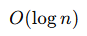

### Геш-таблиця

In [16]:
class HashTable:

    def __init__(self, size):

        self.size = size

        self.table = [[] for _ in range(size)]

    def hash_function(self, key):

        return hash(key) % self.size

    def insert(self, key, value):

        index = self.hash_function(key)

        self.table[index].append((key, value))

    def search(self, key):

        index = self.hash_function(key)

        for k, v in self.table[index]:

            if k == key:
                return v

        return None

    def delete(self, key):

        index = self.hash_function(key)

        for i, (k, v) in enumerate(self.table[index]):

            if k == key:

                del self.table[index][i]

                return

### Перевірка HashTable

In [17]:
ht = HashTable(10)

ht.insert(1, "Python")
ht.insert(2, "Tree")
ht.insert(3, "Heap")

print(ht.search(2))

ht.delete(2)

print(ht.search(2))

Tree
None


### Тестування різних типів даних

In [18]:
ht.insert(10, 123)

ht.insert(11, "hello")

ht.insert(12, [1, 2, 3])

ht.insert(13, {"a": 1})

print(ht.search(10))
print(ht.search(11))
print(ht.search(12))
print(ht.search(13))

123
hello
[1, 2, 3]
{'a': 1}


## Висновок

У ході лабораторної роботи було реалізовано структури даних дерево, купа та геш-таблиця мовою Python. Було досліджено принципи роботи бінарного дерева, операції вставки та видалення елементів. Також було реалізовано max-купу та виконано операції додавання і видалення максимального елемента. Окрім цього, було створено геш-таблицю з ланцюжковим гешуванням та протестовано її роботу з різними типами даних.

## Контрольні питання

### 1. Чим відрізняється структура бінарне дерево від бінарного дерева пошуку?

Бінарне дерево — це структура даних, у якій кожен вузол може мати не більше двох нащадків: лівого і правого.

Бінарне дерево пошуку (BST) — це спеціальний тип бінарного дерева, у якому:
- всі елементи лівого піддерева менші за корінь;
- всі елементи правого піддерева більші за корінь.

Головна відмінність полягає у правилах розташування елементів.


### 2. Чим відрізняється структура бінарне дерево від бінарної купи?

Бінарне дерево — загальна ієрархічна структура без обов’язкових правил впорядкування.

Бінарна купа — це спеціальне повне бінарне дерево, яке задовольняє властивість купи:
- у max-купі батьківський вузол більший за дочірні;
- у min-купі батьківський вузол менший за дочірні.

Купа використовується для швидкого доступу до максимального або мінімального елемента.


### 3. Які існують типи дерев? Опишіть їхні основні характеристики та переваги.

Основні типи дерев:

- бінарне дерево — кожен вузол має не більше двох нащадків;
- бінарне дерево пошуку — забезпечує швидкий пошук елементів;
- AVL-дерево — самобалансоване дерево;
- червоно-чорне дерево — підтримує балансування при вставці і видаленні;
- B-дерево — використовується в базах даних і файлових системах;
- дерево виразів — використовується для обчислення математичних виразів.

Переваги дерев:
- ефективний пошук;
- ієрархічне зберігання даних;
- швидка вставка та видалення елементів.


### 4. Наведіть приклади задач, які ефективно вирішуються за допомогою дерев.

За допомогою дерев ефективно розв’язуються:
- пошук даних;
- сортування;
- зберігання структури каталогів;
- робота з базами даних;
- реалізація компіляторів;
- обробка HTML/XML документів;
- побудова ігрових алгоритмів.


### 5. Як організована купа? Опишіть алгоритми додавання та вилучення елементів з купи.

Купа організована як повне бінарне дерево, яке зазвичай зберігається у масиві.

Алгоритм додавання:
1. Новий елемент додається в кінець купи.
2. Елемент порівнюється з батьківським.
3. Якщо властивість купи порушена — елементи міняються місцями.

Алгоритм вилучення:
1. Видаляється кореневий елемент.
2. Останній елемент переноситься у корінь.
3. Виконується відновлення властивостей купи.


### 6. Які задачі можна ефективно вирішити за допомогою купи? Наведіть приклади.

Купи використовуються для:
- реалізації пріоритетних черг;
- алгоритму Дейкстри;
- сортування Heap Sort;
- планування задач;
- пошуку максимального або мінімального елемента.


### 7. Як геш-функція використовується для зберігання та пошуку даних в хеш-таблиці?

Геш-функція перетворює ключ у числовий індекс масиву.

Під час вставки:
- обчислюється хеш;
- дані зберігаються за відповідним індексом.

Під час пошуку:
- за ключем обчислюється той самий хеш;
- елемент швидко знаходиться за індексом.

Це забезпечує швидкий доступ до даних.


### 8. Опишіть методи вирішення колізій в хеш-таблицях. Які їхні переваги та недоліки?

Основні методи розв’язання колізій:

1. Ланцюжкове гешування
- у кожній комірці зберігається список елементів;
- проста реалізація;
- можливе збільшення часу пошуку.

2. Відкрита адресація
- при колізії шукається інша вільна комірка;
- економить пам’ять;
- складніша реалізація.

3. Подвійне гешування
- використовується друга геш-функція;
- менше колізій;
- складніший алгоритм.

Колізії можуть зменшувати ефективність роботи геш-таблиці.